# Demo 1 — The Five-Minute Model

### Chapter 1 of the open tabular stack: *out-of-the-box*

> **Hyperparameter tuning is a tax. Foundation models pay it once, for everyone.**

| Approach | What it represents |
|---|---|
| `HGBT default` | `fit()` and ship — the lazy baseline |
| `HGBT + Optuna (20 trials)` | What a careful data scientist does — the strong baseline |
| `TabICL default` | What :probabl.'s open stack proposes — `fit()` + `predict()`, no tuning |

Two numbers per model: ROC AUC and total wall-clock time *including* tuning.

In [1]:
import os
import time
import warnings
from contextlib import contextmanager
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
from skrub import TableVectorizer
import optuna
from tabicl import TabICLClassifier
import skore

env_path = Path(".env")
if env_path.exists():
    for line in env_path.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#") and "=" in line:
            k, v = line.split("=", 1)
            os.environ.setdefault(k.strip(), v.strip())

skore.login()

optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams["figure.dpi"] = 110

BLUE = "#1E22AA"
ORANGE = "#F68D2E"
GRAY = "#94A3B8"
DARK = "#1A1A2E"

@contextmanager
def stopwatch(label):
    t0 = time.perf_counter()
    holder = {}
    def elapsed():
        return time.perf_counter() - t0
    yield elapsed
    holder["t"] = time.perf_counter() - t0
    print(f"  [{label}] wall-clock: {holder['t']:.1f}s")


╭───────────────────────────────── Login to Skore Hub ─────────────────────────────────╮
│                                                                                      │
│              Successfully logged in, using interactive authentication.               │
│                                                                                      │
╰──────────────────────────────────────────────────────────────────────────────────────╯

## 1. Data — German credit

1000 rows, 20 mixed features, binary target (`bad` = default risk = positive class).

In [2]:
data = fetch_openml(name="credit-g", version=1, as_frame=True)
X = data.data
y = (data.target == "bad").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print(f"Shape: {X.shape}")
print(f"Class balance: {y.value_counts(normalize=True).round(3).to_dict()}")


Shape: (1000, 20)
Class balance: {0: 0.7, 1: 0.3}


## 2. Three pipelines

Same `TableVectorizer` preprocessor on all three so the comparison is about the model.

In [3]:
results = {}

with stopwatch("HGBT default") as elapsed:
    pipe_default = make_pipeline(
        TableVectorizer(),
        HistGradientBoostingClassifier(random_state=42),
    )
    pipe_default.fit(X_train, y_train)
    auc_default = roc_auc_score(y_test, pipe_default.predict_proba(X_test)[:, 1])
    t_default = elapsed()
results["HGBT default"] = {"auc": auc_default, "time_s": t_default, "color": GRAY}
print(f"  ROC AUC: {auc_default:.4f}")


def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 127),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 100),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-3, 10.0, log=True),
        "max_iter": trial.suggest_int("max_iter", 100, 500),
    }
    pipe = make_pipeline(
        TableVectorizer(),
        HistGradientBoostingClassifier(random_state=42, **params),
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(pipe, X_train, y_train, scoring="roc_auc", cv=cv, n_jobs=-1).mean()

with stopwatch("HGBT + Optuna (20 trials)") as elapsed:
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=20, show_progress_bar=False)
    pipe_tuned = make_pipeline(
        TableVectorizer(),
        HistGradientBoostingClassifier(random_state=42, **study.best_params),
    )
    pipe_tuned.fit(X_train, y_train)
    auc_tuned = roc_auc_score(y_test, pipe_tuned.predict_proba(X_test)[:, 1])
    t_tuned = elapsed()
results["HGBT + Optuna"] = {"auc": auc_tuned, "time_s": t_tuned, "color": BLUE}
print(f"  ROC AUC: {auc_tuned:.4f}")


with stopwatch("TabICL default") as elapsed:
    pipe_tabicl = make_pipeline(
        TableVectorizer(),
        TabICLClassifier(device="cpu", random_state=42),
    )
    pipe_tabicl.fit(X_train, y_train)
    auc_tabicl = roc_auc_score(y_test, pipe_tabicl.predict_proba(X_test)[:, 1])
    t_tabicl = elapsed()
results["TabICL default"] = {"auc": auc_tabicl, "time_s": t_tabicl, "color": ORANGE}
print(f"  ROC AUC: {auc_tabicl:.4f}")


  [HGBT default] wall-clock: 0.4s
  ROC AUC: 0.7934


  [HGBT + Optuna (20 trials)] wall-clock: 17.5s
  ROC AUC: 0.7583
INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.



tabicl-classifier-v2-20260212.ckpt:   0%|          | 0.00/110M [00:00<?, ?B/s]

  [TabICL default] wall-clock: 22.2s
  ROC AUC: 0.8128


In [4]:
report_default = skore.EstimatorReport(
    pipe_default, fit=False,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    pos_label=1,
)
report_tuned = skore.EstimatorReport(
    pipe_tuned, fit=False,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    pos_label=1,
)
report_tabicl = skore.EstimatorReport(
    pipe_tabicl, fit=False,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    pos_label=1,
)

comparison = skore.ComparisonReport(reports={
    "HGBT default": report_default,
    "HGBT + Optuna": report_tuned,
    "TabICL default": report_tabicl,
})

comparison.metrics.summarize().frame()


Compute metric for each estimator ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100%

Estimator,HGBT default,HGBT + Optuna,TabICL default
Metric,,,
Accuracy,0.752000,0.740000,0.776000
Precision,0.618182,0.608696,0.666667
Recall,0.453333,0.373333,0.506667
ROC AUC,0.793371,0.758324,0.812800
Log loss,0.552264,0.519943,0.471998
Brier score,0.173716,0.174376,0.155154
Fit time (s),NaN,NaN,NaN
Predict time (s),0.038312,0.033742,11.126759


Computing display for each report ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100%

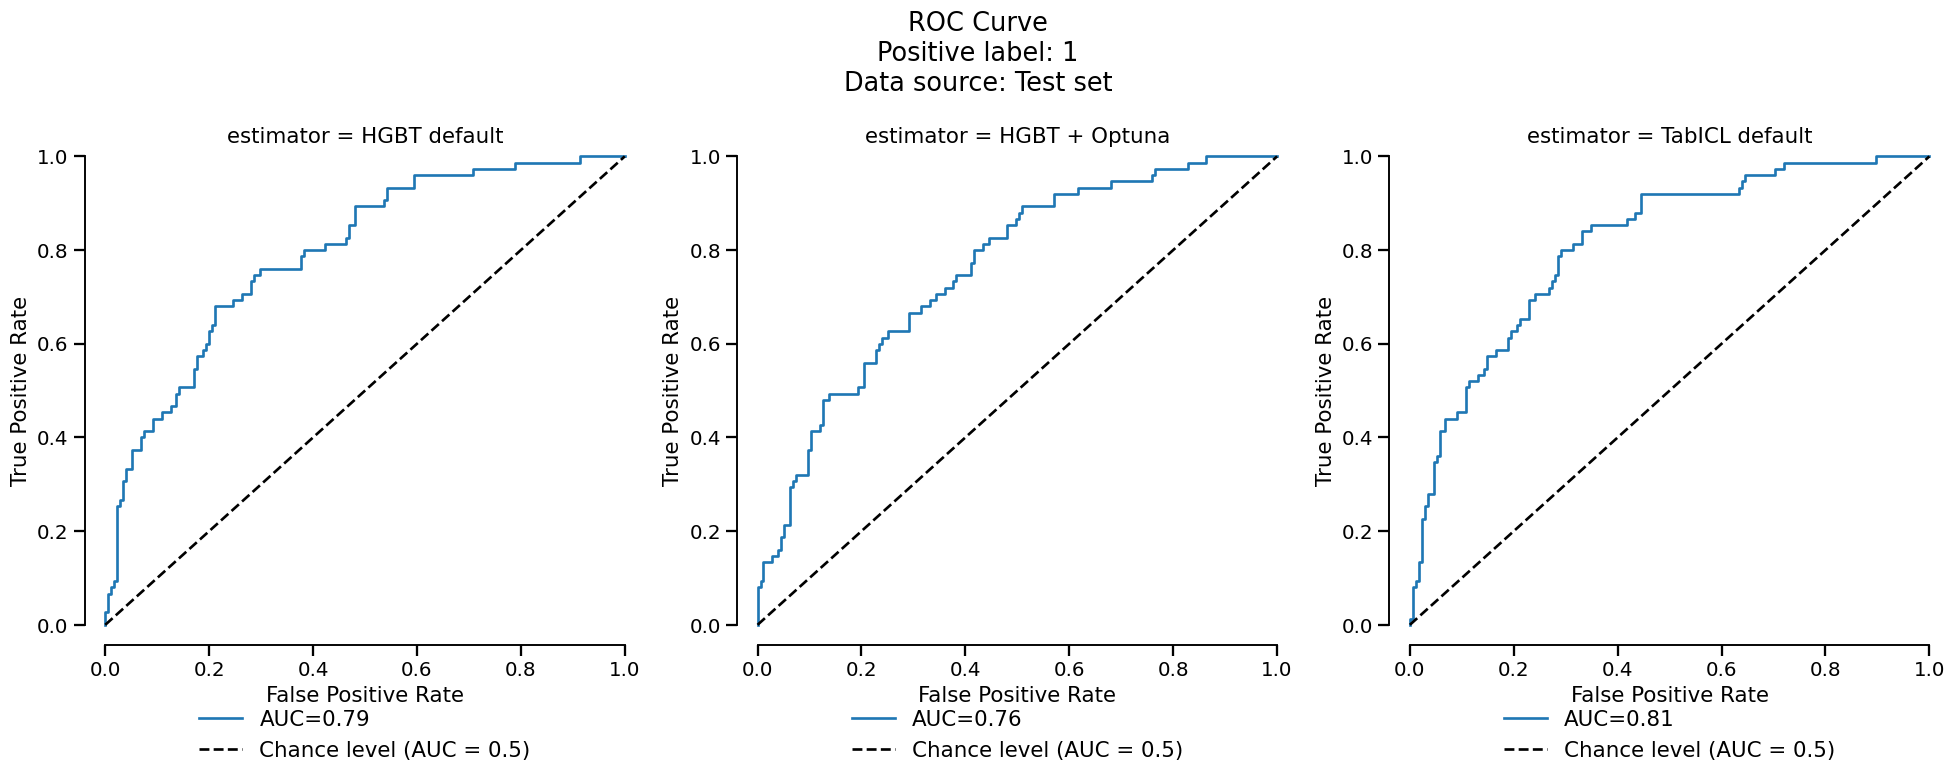

In [11]:
display = comparison.metrics.roc()
display.plot()

Computing display for each report ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100%

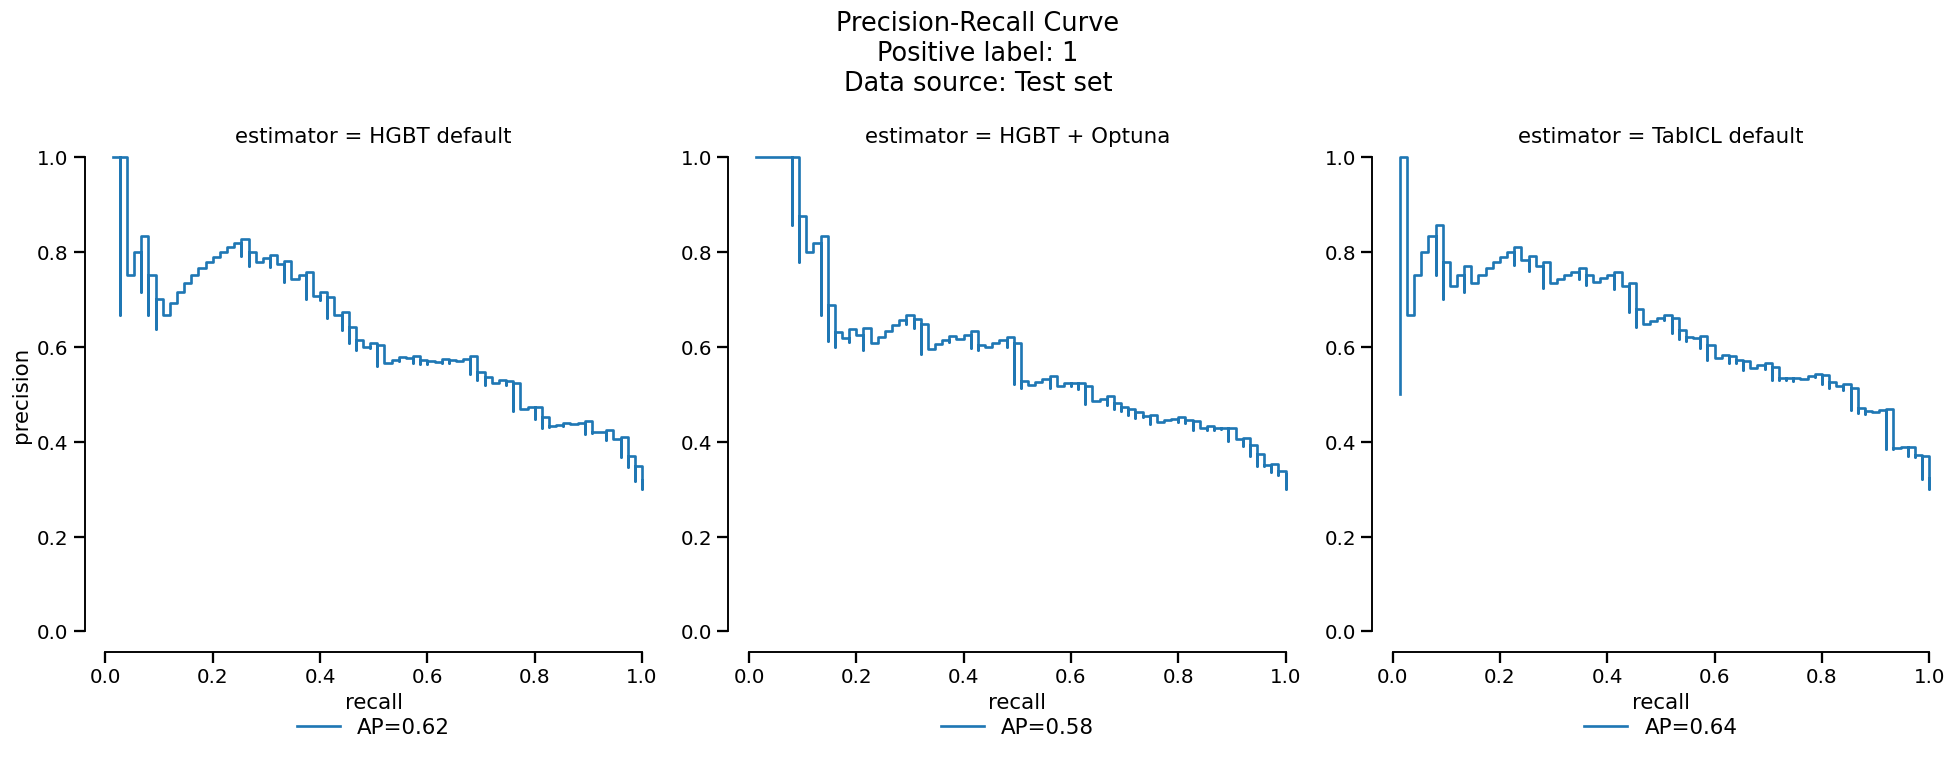

In [10]:
display = comparison.metrics.precision_recall()
display.plot()

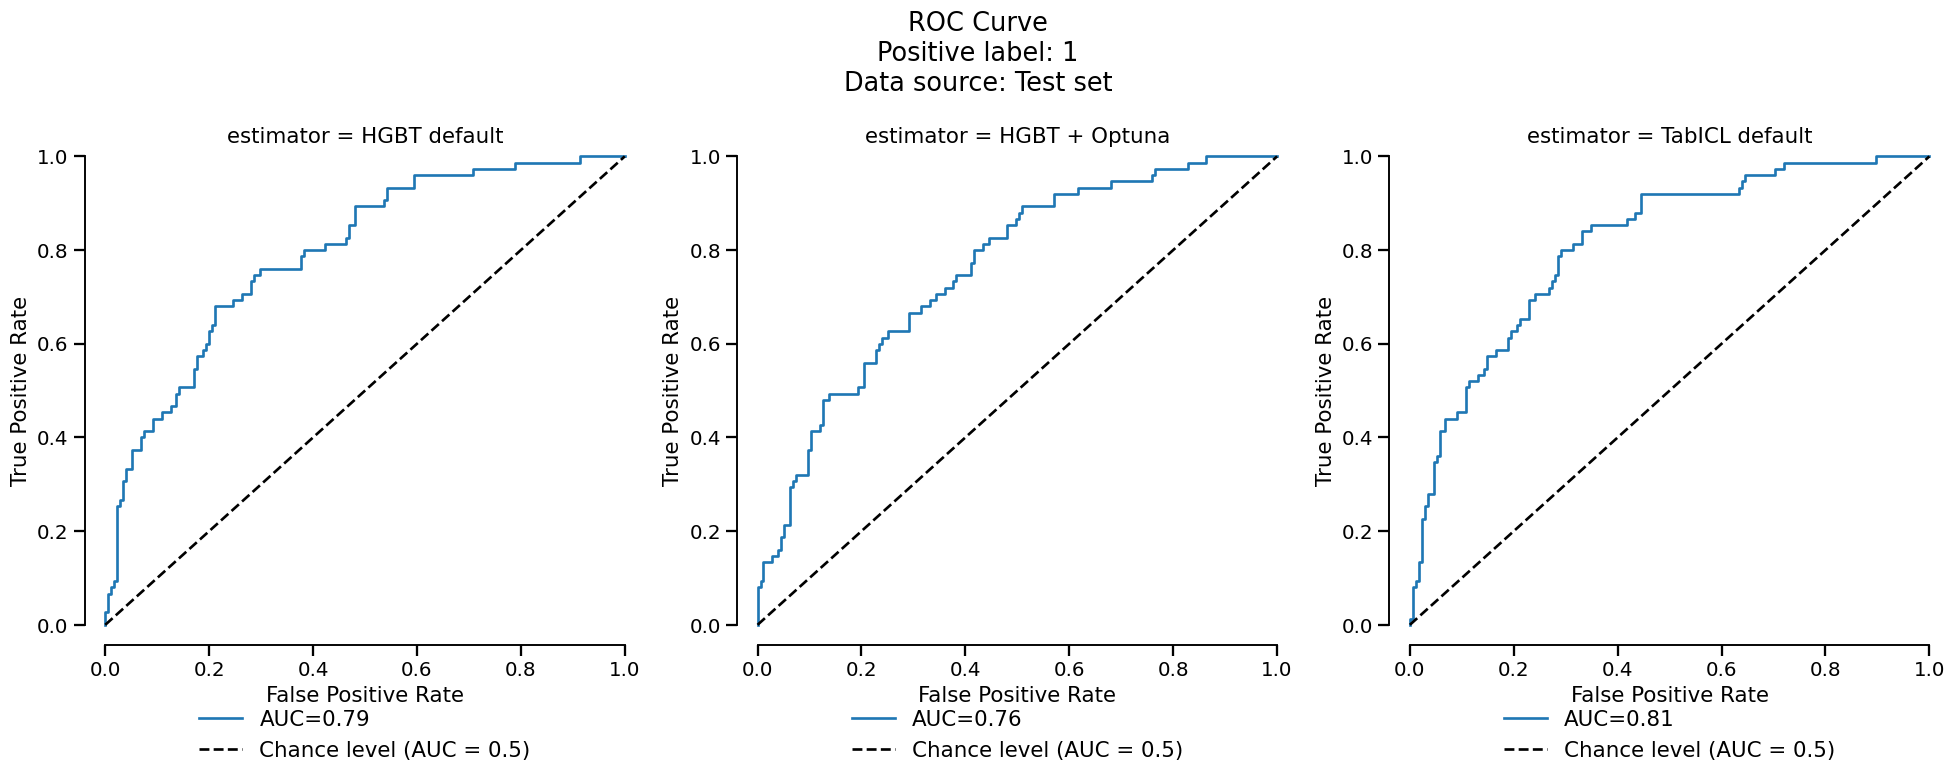

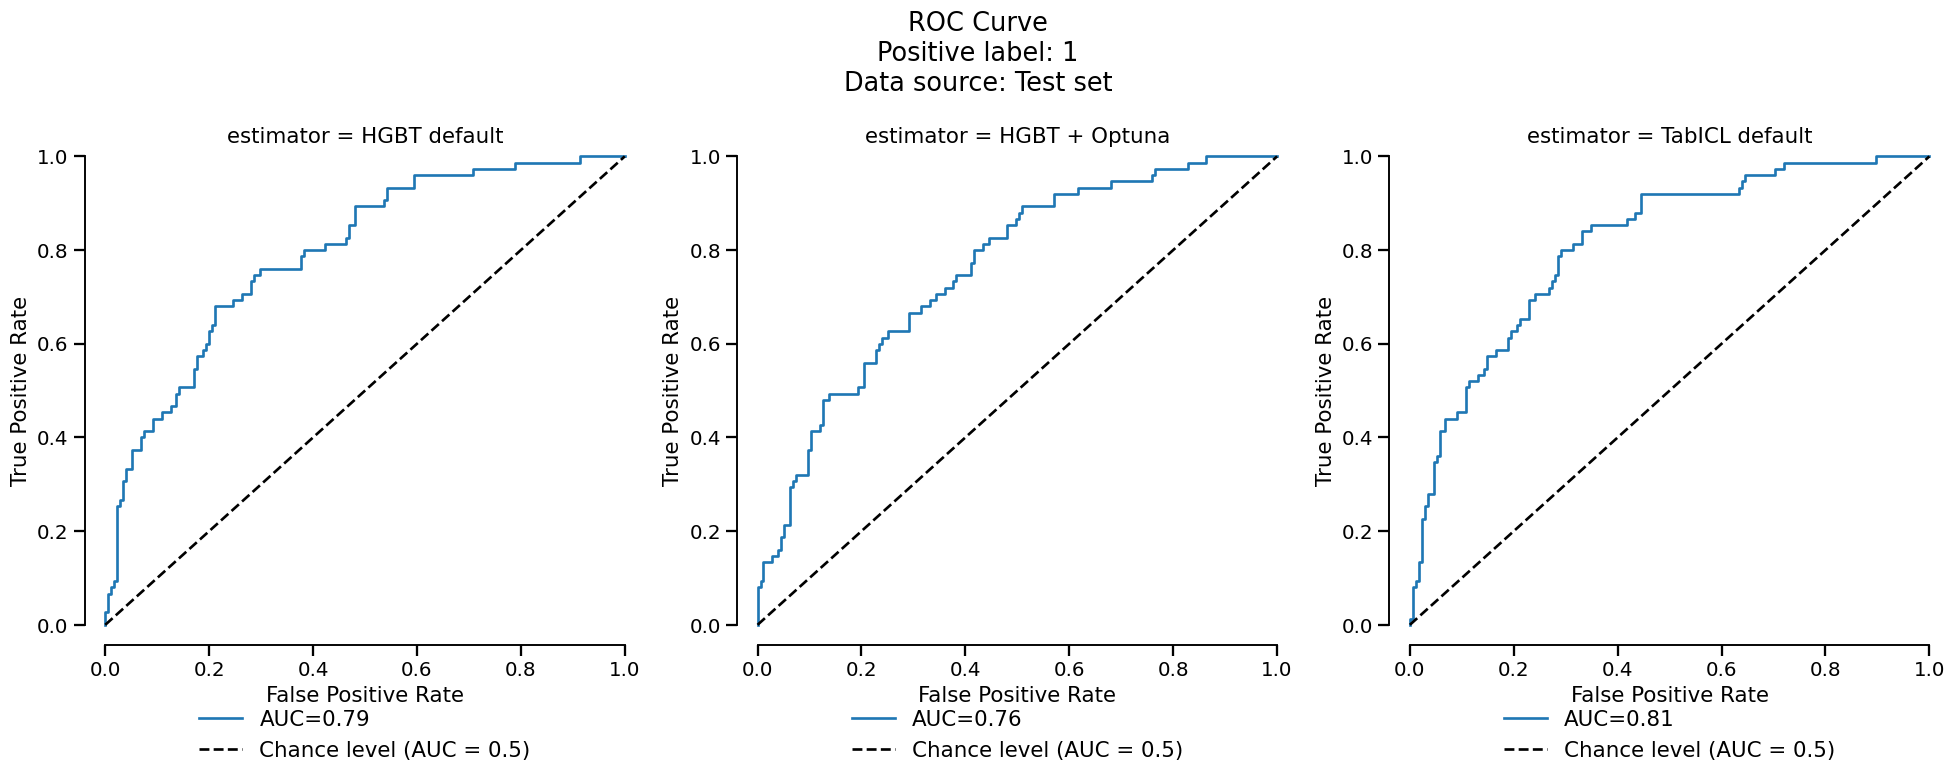

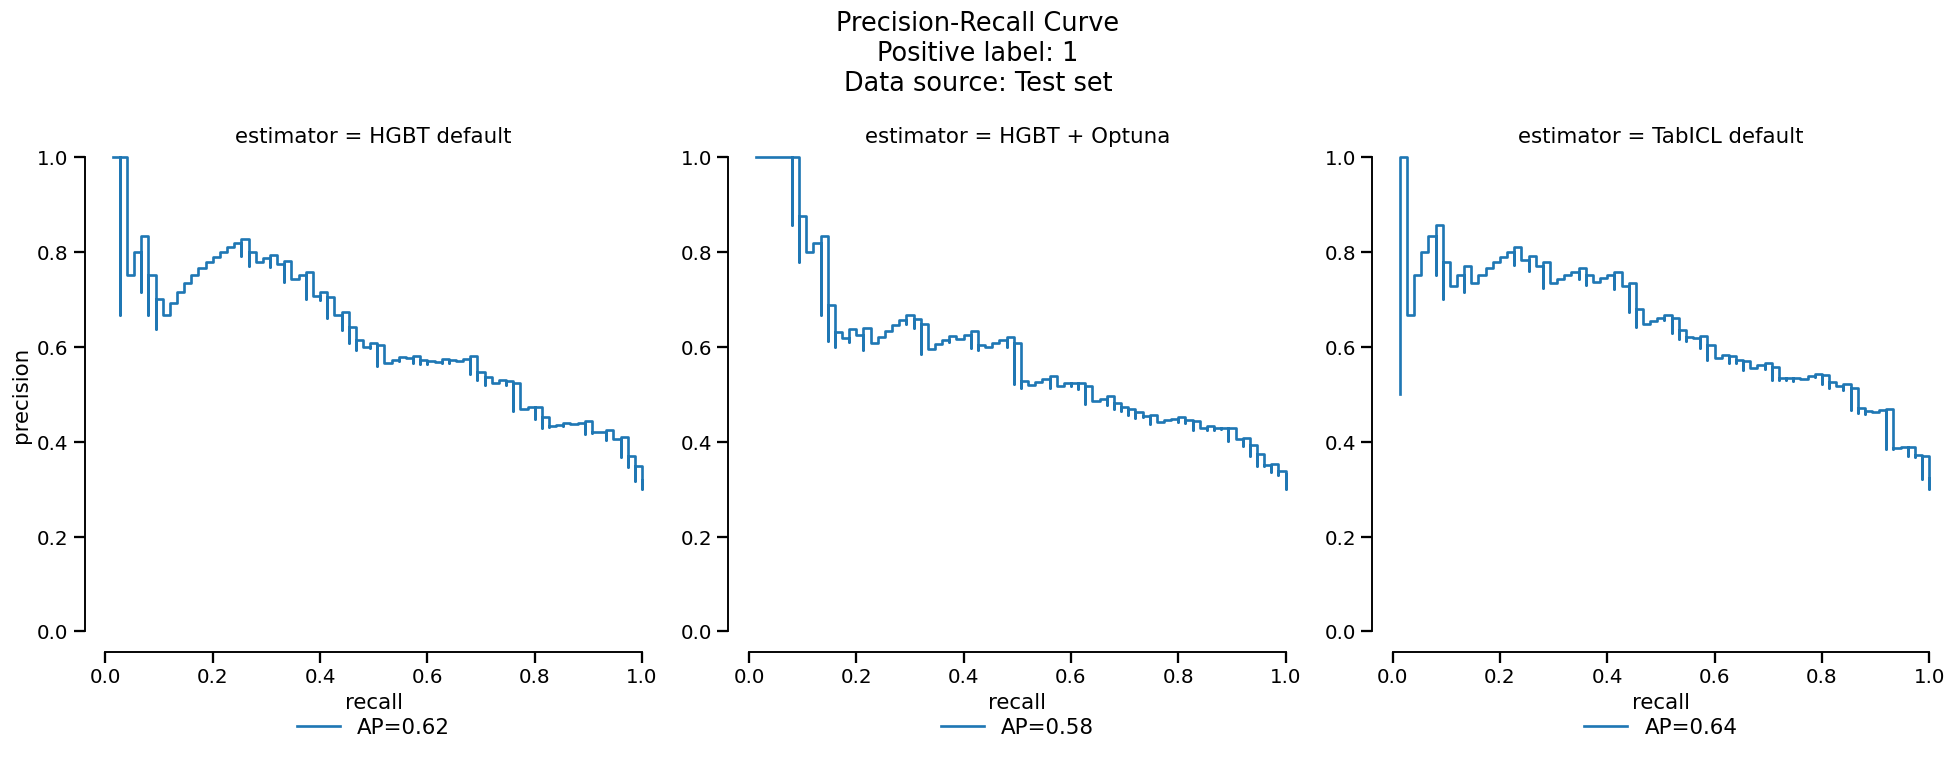

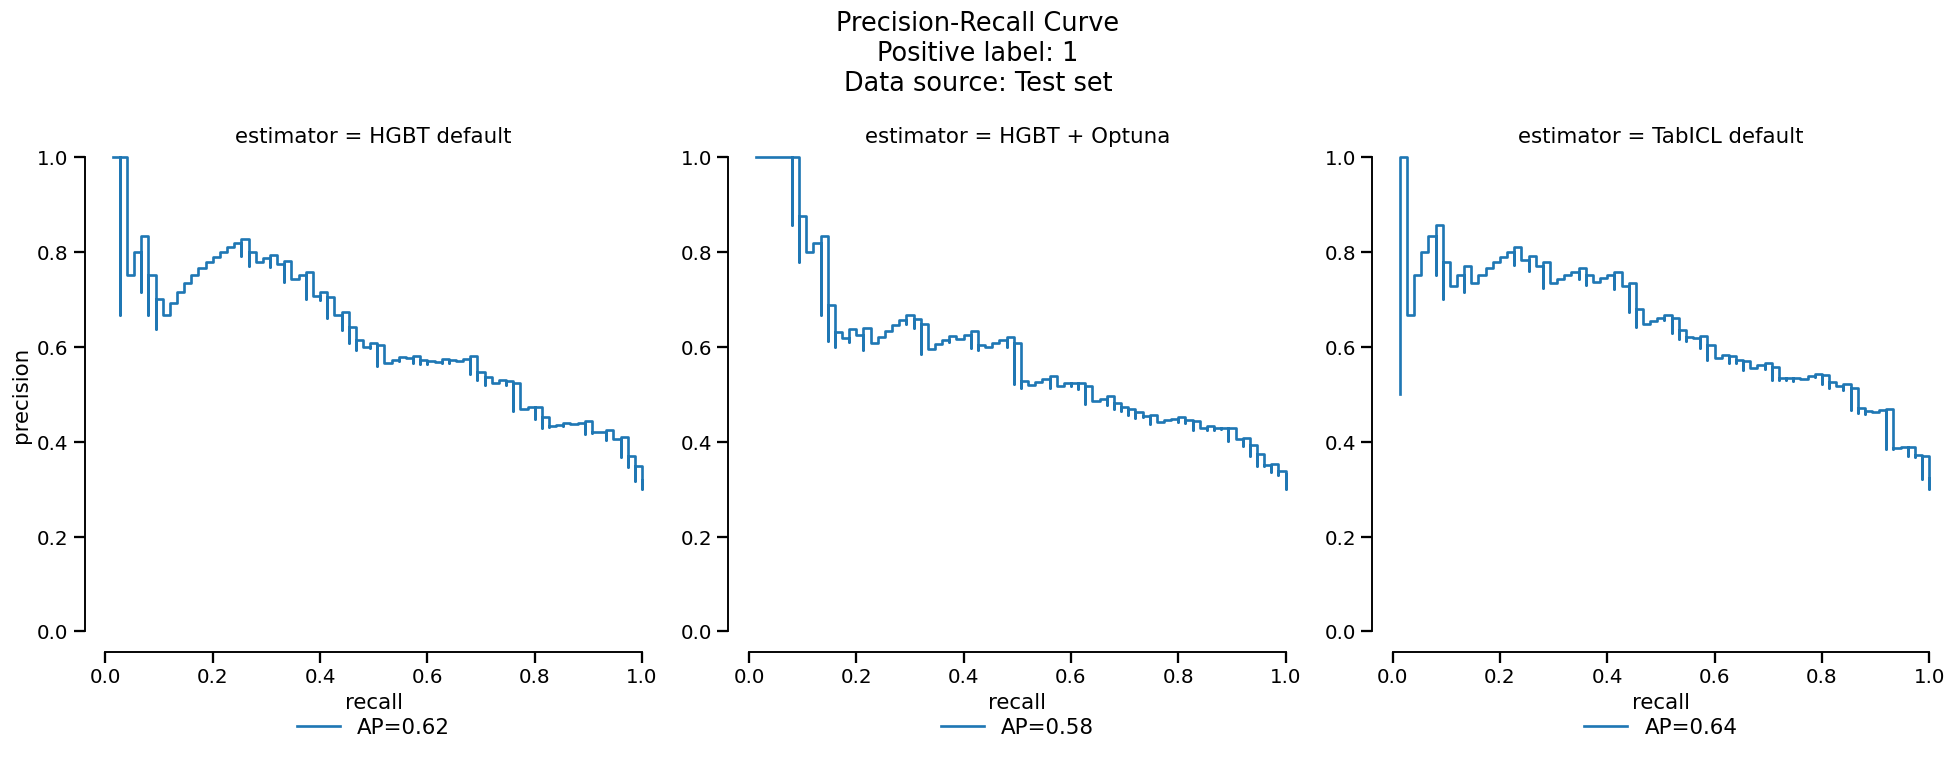

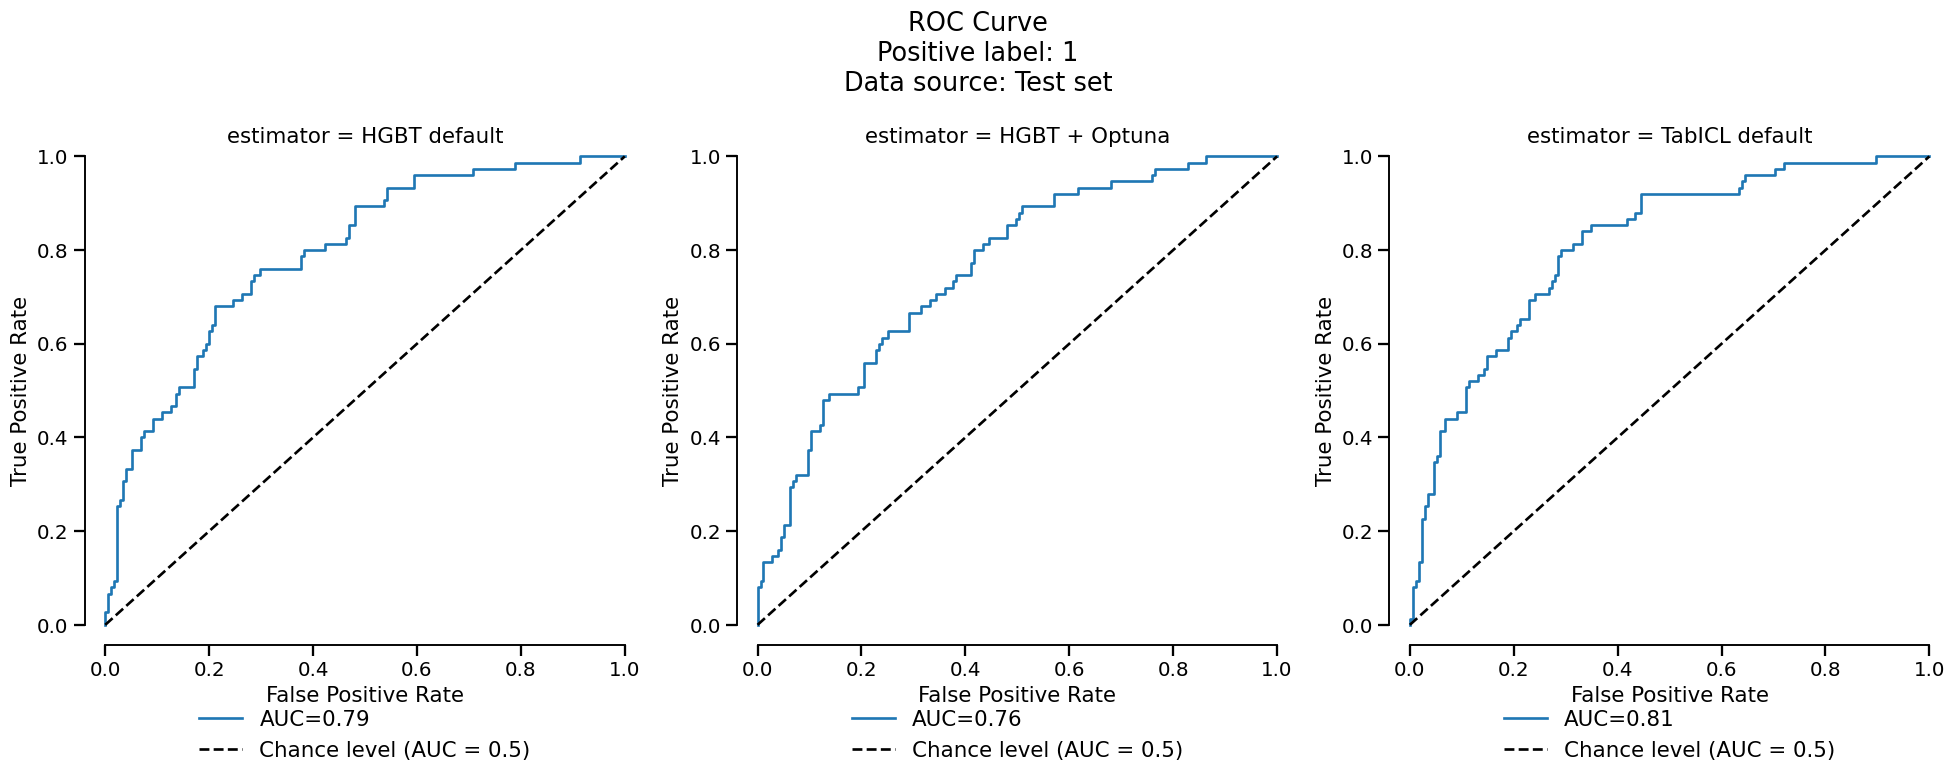

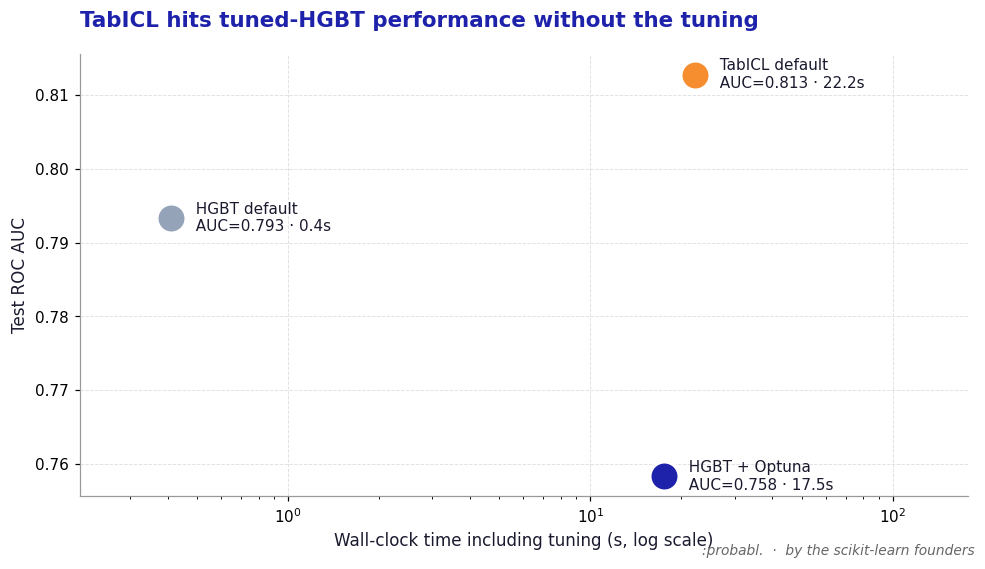

In [12]:
from pathlib import Path

fig, ax = plt.subplots(figsize=(9, 5.2))
for name, r in results.items():
    ax.scatter(
        r["time_s"], r["auc"],
        s=380, color=r["color"],
        edgecolors="white", linewidths=2.5, zorder=3,
        label=name,
    )
    ax.annotate(
        f"  {name}\n  AUC={r['auc']:.3f} · {r['time_s']:.1f}s",
        (r["time_s"], r["auc"]),
        textcoords="offset points", xytext=(10, 0),
        fontsize=10, color=DARK, va="center",
    )

times = [r["time_s"] for r in results.values()]
ax.set_xscale("log")
ax.set_xlabel("Wall-clock time including tuning (s, log scale)", color=DARK, fontsize=11)
ax.set_ylabel("Test ROC AUC", color=DARK, fontsize=11)
ax.set_title(
    "TabICL hits tuned-HGBT performance without the tuning",
    color=BLUE, fontsize=14, fontweight="bold", loc="left", pad=18,
)
ax.set_xlim(left=min(times) * 0.5, right=max(times) * 8.0)
ax.grid(True, color="#E0E0E0", linestyle="--", linewidth=0.6, zorder=0)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["bottom", "left"]:
    ax.spines[spine].set_color("#999999")

fig.text(0.99, 0.02, ":probabl.  ·  by the scikit-learn founders",
         ha="right", color="#666666", fontsize=9, style="italic")

plt.tight_layout()
out = Path("recordings/final/demo1_chart.png")
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


In [13]:
project = skore.Project("debray.yann/demo1-five-minute-model", mode="hub")
project.put("hgbt-default", report_default)
project.put("hgbt-tuned", report_tuned)
project.put("tabicl-default", report_tabicl)
print(f"https://skore.probabl.ai/{project.name}")


ForbiddenException: You are not member of the workspace debray.yann.